## Parte 1) Entrenamiento y Evaluación de Modelo Fine-Tuned
**Objetivo:** Entrenar un modelo de lenguaje personalizado mediante fine-tuning, desplegarlo y evaluar su rendimiento mediante pruebas comparativas y análisis de métricas.

### 1.1 - Preparación del Dataset de Fine-Tuning

Crea o selecciona un dataset personalizado que defina el comportamiento deseado para tu modelo fine-tuned.

**Requisitos del dataset:**
- Formato **JSONL** (JSON Lines) compatible con Chat Completions API
- Mínimo **50-100 ejemplos** de conversaciones (recomendado: 100-300 para mejores resultados)
- Estructura conversacional con roles: `system`, `user`, `assistant`
- División en dos archivos:
  - `training_set.jsonl` (80% de los datos)
  - `validation_set.jsonl` (20% de los datos)

**Ejemplos de casos de uso:**
- Chatbot de soporte técnico especializado en un tema específico
- Asistente que responde con un tono/estilo particular (formal, casual, sarcástico, etc.)
- Generador de contenido en formato específico (JSON, XML, markdown estructurado)
- Asistente de código especializado en un lenguaje o framework
- Sistema de respuestas basado en documentación interna

In [2]:
# Primeras 5 líneas del archivo validation_set.jsonl
with open('datagen-626c18-validation_set.jsonl') as f:
    for i, line in enumerate(f):
        if i < 5:
            print(line.strip())
        else:
            break

{"messages": [{"role": "system", "content": "You are a helpful assistant. You will be presented with a question, please provide a clear and accurate answer."}, {"role": "user", "content": "What type of data does the Xeno-canto API provide for species classification?"}, {"role": "assistant", "content": "The Xeno-canto API provides audio recordings and associated metadata for bioacoustic classification of species. This includes sound files of animal vocalizations, which are useful for identifying species based on their acoustic signatures, as well as additional information such as location and recording details."}]}
{"messages": [{"role": "system", "content": "You are a helpful assistant. You will be presented with a question, please provide a clear and accurate answer."}, {"role": "user", "content": "Which repository offers time series data on animal movement and migration?"}, {"role": "assistant", "content": "Movebank is a data repository offering time series data on animal movement an

In [3]:
# Primeras 5 líneas del archivo Data-zoology.jsonl
with open('datagen-c5ec03-Data-zoology.jsonl') as f:
    for i, line in enumerate(f):
        if i < 5:
            print(line.strip())
        else:
            break

{"messages": [{"role": "system", "content": "You are a helpful assistant. You will be presented with a question, please provide a clear and accurate answer."}, {"role": "user", "content": "What type of data can be obtained from the EOL TraitBank?"}, {"role": "assistant", "content": "EOL TraitBank provides data related to biological attributes, specifically focusing on physical traits and dietary information of organisms. This resource is intended for training datasets that require detailed information about organism characteristics."}]}
{"messages": [{"role": "system", "content": "You are a helpful assistant. You will be presented with a question, please provide a clear and accurate answer."}, {"role": "user", "content": "Explain the main focus of the Catalogue of Life resource."}, {"role": "assistant", "content": "The main focus of the Catalogue of Life resource is to offer a pure taxonomic structure and valid names for organisms. It serves as a reference for taxonomic checklists, ens

### 1.2 - Entrenamiento del Modelo (elegir una modalidad)

Realiza el fine-tuning de un modelo de Azure OpenAI usando el dataset preparado. **Elige UNA de las dos modalidades:**

#### 🖥️ Opción A - Modalidad Portal (Azure AI Foundry Studio)

Si eliges esta modalidad:
- Accede a [Azure AI Foundry](https://ai.azure.com/)
- Navega a la sección **Fine-tuning** y crea un nuevo trabajo
- Configura:
  - **Modelo base**: GPT-4o-mini, GPT-4o, u otro disponible
  - **Training type**: Standard, Global o Developer (justifica tu elección)
  - **Hiperparámetros**: Puedes usar valores automáticos o ajustarlos manualmente
  - **Suffix**: Nombre descriptivo para tu modelo (ej: "soporte-azure-v1")
- Sube los archivos `training_set.jsonl` y `validation_set.jsonl`
- Monitorea el progreso del entrenamiento


**Respuesta - Opción A seleccionada:**

**Configuración elegida para el modelo base:**
- **Modelo base**: GPT-4.1
- **Training type**: Global
- **Type**: Standard
- **Model Zoo**: Habilitado para acceso a modelos adicionales


**Justificación de la elección:**

- **Global**: Seleccionado para optimización global del modelo en diferentes regiones/contextos
- **Standard**: Modalidad estándar de entrenamiento con configuración automática de hiperparámetros


** Enlace al video del proceso:**

https://tajamar365-my.sharepoint.com/:v:/p/marcos_calvo/IQCJ2koCqkhXQZXILDas-dkRAeky9t-gtqg9hyOx_v5cHrg?nav=eyJyZWZlcnJhbEluZm8iOnsicmVmZXJyYWxBcHAiOiJPbmVEcml2ZUZvckJ1c2luZXNzIiwicmVmZXJyYWxBcHBQbGF0Zm9ybSI6IldlYiIsInJlZmVycmFsTW9kZSI6InZpZXciLCJyZWZlcnJhbFZpZXciOiJNeUZpbGVzTGlua0NvcHkifX0&e=GMggNa



### 1.3 - Despliegue del Modelo Fine-Tuned

Una vez completado el entrenamiento con éxito (`succeeded`), despliega tu modelo fine-tuned:

**Configuración del deployment:**
- **Deployment name**: Nombre descriptivo (ej: "chatbot-soporte-v1")
- **Tokens per minute (TPM)**: Configura según tus necesidades (puede ser el mínimo para pruebas)

**Opciones de despliegue:**
- Desde el portal: Sección Fine-tuning → Selecciona tu modelo → Deploy
- Con Python SDK: Usa el SDK de Azure AI para crear el deployment programáticamente

Guarda la información del endpoint y deployment name para las pruebas.

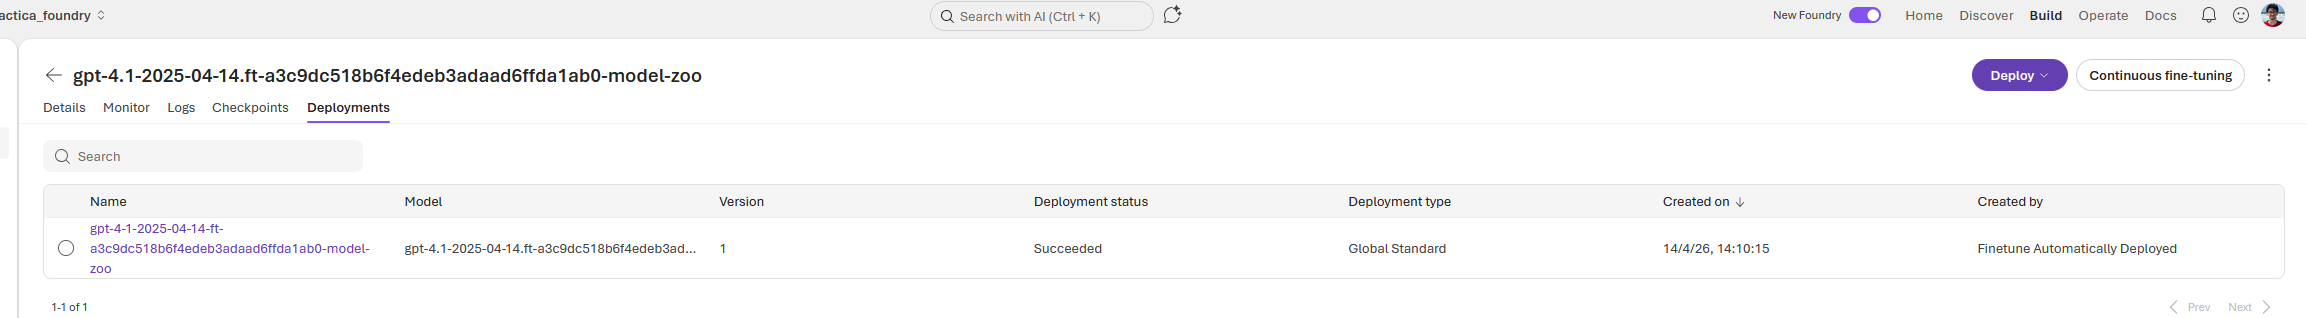

### 1.4 - Pruebas y Evaluación del Modelo

Crea pruebas exhaustivas de tu modelo fine-tuned y compara su rendimiento con el modelo base.

**Pruebas a realizar:**

1. **Casos de uso del dataset**: Prueba ejemplos similares a los del entrenamiento
2. **Casos fuera del dataset**: Evalúa generalización con casos nuevos
3. **Casos edge**: Prueba situaciones límite o inusuales
4. **Comparación directa**: Misma pregunta al modelo base y al fine-tuned

**Análisis de métricas:**

Analiza las siguientes métricas del entrenamiento (disponibles en el portal o via API):

- **`training_loss`**: Pérdida en los datos de entrenamiento
  - Debe **disminuir** a lo largo de las épocas
  - Si no disminuye: problemas con datos o hiperparámetros
  
- **`validation_loss`**: Pérdida en los datos de validación
  - Debe **disminuir** de manera similar al training_loss
  - Si aumenta mientras training_loss baja: **overfitting**

In [7]:
import os
from dotenv import load_dotenv
from openai import OpenAI

# Load environment variables from .env file
load_dotenv()

endpoint_ft = os.getenv("AZURE_OPENAI_ENDPOINT_ft")
deployment_name_ft = os.getenv("AZURE_OPENAI_DEPLOYMENT_ft")
api_key_ft = os.getenv("AZURE_OPENAI_API_KEY_ft")

In [6]:
import os
from dotenv import load_dotenv
from openai import OpenAI

# Load environment variables from .env file
load_dotenv()

endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
deployment_name = os.getenv("AZURE_OPENAI_DEPLOYMENT")
api_key = os.getenv("AZURE_OPENAI_API_KEY")

In [9]:
#Casos de uso del dataset
from openai import OpenAI


client = OpenAI(
    base_url=endpoint_ft,
    api_key=api_key_ft
)

completion = client.chat.completions.create(
    model=deployment_name_ft,
    messages=[
        {
            "role": "user",
            "content": "For which group of animals does PanTHERIA provide a dense dataset of ecological traits?",
        }
    ],
)

print(completion.choices[0].message.content)

PanTHERIA provides a dense dataset of ecological traits specifically for mammals. It is particularly noted for its comprehensive coverage of life history, ecological, and geographical attributes in this taxonomic group. This makes it a key resource for studies on mammalian biology and comparative ecology.


In [12]:
#Casos fuera del dataset
from openai import OpenAI

client = OpenAI(
    base_url=endpoint_ft,
    api_key=api_key_ft
)

completion = client.chat.completions.create(
    model=deployment_name_ft,
    messages=[{
        "role": "user",
        "content": "What other ecological datasets exist similar to PanTHERIA?"
    }]
)
print(completion.choices[0].message.content)


PanTHERIA is a well-known ecological trait database, primarily offering species-level data on mammalian life history, ecology, and geography. If you’re seeking similar datasets—those focused on ecological traits, diet, or environmental associations—here are several relevant alternatives:

### 1. EltonTraits
- **Description:** Provides species-level data on diet, foraging behavior, and ecological niches for birds and mammals.
- **Key Features:** Focus on trophic ecology and functional traits.
- **Use Cases:** Analyses of food webs, functional diversity, and ecological roles.
- **Access:** [EltonTraits database](https://figshare.com/articles/dataset/EltonTraits_1_0_Species-level_foraging_attributes_of_the_world_s_birds_and_mammals/3559887)

### 2. AnAge Database
- **Description:** Contains detailed information about life history traits, longevity, and ageing for vertebrates.
- **Key Features:** Emphasis on lifespan and reproductive data.
- **Use Cases:** Comparative analyses of aging, li

In [13]:
#Casos edge
from openai import OpenAI

client = OpenAI(
    base_url=endpoint_ft,
    api_key=api_key_ft
)


completion = client.chat.completions.create(
    model=deployment_name_ft,
    messages=[{
        "role": "user",
        "content": "Tell me about animals in PanTHERIA"
    }]
)
print(completion.choices[0].message.content)

**PanTHERIA** is a database and resource focused on ecological and life-history characteristics of mammals. It’s widely used for training machine learning models and conducting macroecological studies. The dataset covers a variety of biological attributes for over 5,000 mammal species, enabling researchers to explore patterns in physiology, ecology, and evolutionary biology.

**Key Features and Insights:**

- **Ecological Traits:** PanTHERIA provides data on dietary habits, habitat preferences, and foraging behaviors, which are crucial for understanding different ecological roles.
- **Life-History Traits:** Attributes such as lifespan, reproductive rates, and body size are included, allowing studies on survival strategies and growth patterns.
- **Environmental Associations:** The database links species with their environmental contexts, including biogeography and climate preferences, facilitating analyses of species distributions in relation to ecological variables.

**Applications:**


In [16]:
#Comparación directa: Modelo base vs Modelo Fine-Tuned
from openai import OpenAI

test_question = "For which group of animals does PanTHERIA provide a dense dataset of ecological traits?"


print("RESPUESTA DEL MODELO FINE-TUNED:")
client_ft = OpenAI(
    base_url=endpoint_ft,
    api_key=api_key_ft
)
completion_ft = client_ft.chat.completions.create(
    model=deployment_name_ft,
    messages=[{"role": "user", "content": test_question}]
)
print(completion_ft.choices[0].message.content)


print("RESPUESTA DEL MODELO BASE:")
client_base = OpenAI(
    base_url=endpoint,
    api_key=api_key
)
completion_base = client_base.chat.completions.create(
    model=deployment_name,
    messages=[{"role": "user", "content": test_question}]
)
print(completion.choices[0].message.content)


RESPUESTA DEL MODELO FINE-TUNED:
PanTHERIA provides a dense dataset of ecological traits for mammals. The resource is described as a "Trait database," specifically structured around ecological and environmental variables, making it particularly valuable for studies on mammalian life history and ecological characteristics. According to the text, PanTHERIA offers quantitative traits related to ecology for mammals, facilitating trait-based analyses in zoological research.
RESPUESTA DEL MODELO BASE:
**PanTHERIA** is a database and resource focused on ecological and life-history characteristics of mammals. It’s widely used for training machine learning models and conducting macroecological studies. The dataset covers a variety of biological attributes for over 5,000 mammal species, enabling researchers to explore patterns in physiology, ecology, and evolutionary biology.

**Key Features and Insights:**

- **Ecological Traits:** PanTHERIA provides data on dietary habits, habitat preferences,